# Model Comparison — YOLO26n vs YOLO11n vs SSDLite

Three detectors trained on the same Construction-PPE data, compared properly.

| | YOLO26n | YOLO11n | YOLO11s | SSDLite320 |
|---|---|---|---|---|
| Family | YOLO, anchor-free | YOLO, anchor-free | YOLO, anchor-free | SSD, anchor-based |
| Backbone | CSP-style CNN | C3k2 + C2PSA | C3k2 + C2PSA (wider) | MobileNetV3-Large |
| Framework | Ultralytics | Ultralytics | Ultralytics | torchvision |
| Input | 640 px | 640 px | 640 px | 320 px |
| Params | 2.51 M | 2.59 M | **9.46 M** | 2.35 M |

Three of these sit within 12% of each other on parameter count, so differences between
them are about **architecture**. YOLO11s is the deliberate exception: same architecture
as YOLO11n, scaled up 3.7x, and therefore a clean test of **capacity** with everything
else held constant.

That second comparison is the interesting one. Every nano model scored 0.01-0.16 on the
four `no_*` classes, and the per-class evidence pointed at the dataset rather than the
models. YOLO11s is how that claim gets tested: if 3.7x the parameters lifts those
classes substantially, the diagnosis was wrong. If it does not, the data explanation
survives a serious attempt to break it.

---

## Why this notebook re-evaluates everything

**The numbers printed by the three training notebooks are not comparable.**

YOLO26n and YOLO11n are scored by Ultralytics' own mAP code. SSDLite is scored by
`torchmetrics`. Both claim to implement COCO mAP, but they differ in:

- the confidence floor applied before matching
- the cap on detections per image (Ultralytics 300, torchmetrics 100 by default)
- how classes with no ground-truth instances are averaged

Those differences are small but not negligible — easily a couple of points of mAP, which
is the same order as the gap between the two YOLOs. Putting the published figures in one
table and declaring a winner would be measuring the metric implementations, not the models.

So everything below is recomputed:

1. **One metric** — `torchmetrics.MeanAveragePrecision`, identical settings for all three.
2. **One split** — the same 143 validation images, in the same order.
3. **One coordinate space** — every box mapped back to *original image pixels*, so the
   320 px model and the 640 px models are judged on identical ground truth.
4. **One confidence floor** — 0.001, low enough not to truncate any model's PR curve.

## 1. Setup

In [1]:
import os, sys, time, json, platform, warnings
from pathlib import Path
from collections import Counter, defaultdict

os.environ.setdefault("PYTORCH_ENABLE_MPS_FALLBACK", "1")
os.environ.setdefault("OMP_NUM_THREADS", "4")
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import cv2
from torchmetrics.detection import MeanAveragePrecision
from ultralytics import YOLO
from torchvision.models.detection import ssdlite320_mobilenet_v3_large
from torchvision.models.detection.ssdlite import SSDLiteClassificationHead
from torchvision.models.detection import _utils as det_utils
from functools import partial

%matplotlib inline
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 9

PROJECT = Path.cwd()
if not (PROJECT / "scripts").exists() and (PROJECT.parent / "scripts").exists():
    PROJECT = PROJECT.parent

DATA_ROOT   = PROJECT / "dataset" / "construction-ppe"
TRAINED_DIR = PROJECT / "trained_model"
OG_DIR      = PROJECT / "og_model"
RUNS_DIR    = PROJECT / "runs"
OUT_DIR     = PROJECT / "comparison"
OUT_DIR.mkdir(exist_ok=True)

CLASS_NAMES = {0: "helmet", 1: "gloves", 2: "vest", 3: "boots", 4: "goggles",
               5: "none", 6: "Person", 7: "no_helmet", 8: "no_goggle",
               9: "no_gloves", 10: "no_boots"}
IMG_EXT = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

if torch.cuda.is_available():
    DEVICE, BACKEND = torch.device("cuda:0"), "cuda"
elif bool(getattr(torch.backends, "mps", None)) and torch.backends.mps.is_available():
    DEVICE, BACKEND = torch.device("mps"), "mps"
else:
    DEVICE, BACKEND = torch.device("cpu"), "cpu"

def sync():
    if BACKEND == "cuda": torch.cuda.synchronize()
    elif BACKEND == "mps": torch.mps.synchronize()

print(f"device  : {DEVICE}")
print(f"project : {PROJECT}")
print()
for f in sorted(TRAINED_DIR.glob("*_best.pt")):
    print(f"  {f.name:<24} {f.stat().st_size/1024**2:>7.2f} MB")

device  : mps
project : /Users/shamprakashr/Documents/VibeCoding/Agent Skills/PPE_Detection

  ssdlite_best.pt             9.21 MB
  yolo11n_best.pt             5.22 MB
  yolo11s_best.pt            18.30 MB
  yolo26n_best.pt             5.15 MB


## 2. Load the three trained models

SSDLite needs its head rebuilt before the weights will load — the saved state dict has a
12-class head, while a freshly constructed model has COCO's 91. Loading without the swap
fails on a shape mismatch.

In [2]:
NUM_CLASSES = 12                      # 11 PPE + background (torchvision convention)
SSD_IMGSZ   = 320
YOLO_IMGSZ  = 640

models = {}

# --- the two Ultralytics models ------------------------------------------
for tag, fname in [("YOLO26n", "yolo26n_best.pt"), ("YOLO11n", "yolo11n_best.pt"),
                   ("YOLO11s", "yolo11s_best.pt")]:
    p = TRAINED_DIR / fname
    if p.exists():
        m = YOLO(str(p))
        models[tag] = {"kind": "yolo", "model": m, "imgsz": YOLO_IMGSZ, "path": p,
                       "params": sum(q.numel() for q in m.model.parameters()),
                       "size_mb": p.stat().st_size / 1024**2}
        print(f"{tag:<9} loaded  {models[tag]['params']/1e6:.2f} M params")
    else:
        print(f"{tag:<9} MISSING at {p} — train notebook 01/02 first")

# --- the torchvision model ------------------------------------------------
p = TRAINED_DIR / "ssdlite_best.pt"
if p.exists():
    ssd = ssdlite320_mobilenet_v3_large(weights=None, weights_backbone=None)
    in_ch  = det_utils.retrieve_out_channels(ssd.backbone, (SSD_IMGSZ, SSD_IMGSZ))
    n_anch = ssd.anchor_generator.num_anchors_per_location()
    ssd.head.classification_head = SSDLiteClassificationHead(
        in_ch, n_anch, NUM_CLASSES, partial(nn.BatchNorm2d, eps=0.001, momentum=0.03))
    ssd.load_state_dict(torch.load(p, map_location="cpu", weights_only=True))
    ssd.to(DEVICE).eval()
    models["SSDLite"] = {"kind": "ssd", "model": ssd, "imgsz": SSD_IMGSZ, "path": p,
                         "params": sum(q.numel() for q in ssd.parameters()),
                         "size_mb": p.stat().st_size / 1024**2}
    print(f"{'SSDLite':<9} loaded  {models['SSDLite']['params']/1e6:.2f} M params")
else:
    print(f"SSDLite   MISSING at {p} — train notebook 03 first")

assert models, "No trained models found."
ORDER = [k for k in ("YOLO26n", "YOLO11n", "YOLO11s", "SSDLite") if k in models]
COLORS = {"YOLO26n": "#1f77b4", "YOLO11n": "#2ca02c",
          "YOLO11s": "#9467bd", "SSDLite": "#d62728"}
print(f"\nComparing: {', '.join(ORDER)}")

YOLO26n   loaded  2.51 M params
YOLO11n   loaded  2.59 M params
YOLO11s   loaded  9.43 M params
SSDLite   loaded  2.35 M params

Comparing: YOLO26n, YOLO11n, YOLO11s, SSDLite


## 3. One evaluation harness for all three

Ground truth comes straight from the YOLO `.txt` files, converted to absolute pixel
coordinates in the **original** image. Each model then predicts at its own native input
size, and its boxes are scaled back into that same original-image space before scoring.

That scaling is the part that makes the comparison fair. Ultralytics already returns
boxes in original coordinates; torchvision returns them in the resized 320×320 frame, so
SSDLite's need an explicit rescale. Skipping it would shrink every SSDLite box by the
resize ratio and make the model look far worse than it is.

In [3]:
VAL_DIR = DATA_ROOT / "images" / "val"
LBL_DIR = DATA_ROOT / "labels" / "val"
val_images = sorted(p for p in VAL_DIR.glob("*") if p.suffix.lower() in IMG_EXT)
print(f"{len(val_images)} validation images")

def ground_truth(img_path):
    """YOLO normalised cxcywh -> absolute xyxy in the ORIGINAL image."""
    img = cv2.imread(str(img_path))
    h, w = img.shape[:2]
    boxes, labels = [], []
    lbl = LBL_DIR / f"{img_path.stem}.txt"
    if lbl.exists():
        for line in lbl.read_text().strip().splitlines():
            parts = line.split()
            if len(parts) < 5:
                continue
            c = int(parts[0]); cx, cy, bw, bh = (float(v) for v in parts[1:5])
            x1, y1 = (cx - bw/2)*w, (cy - bh/2)*h
            x2, y2 = (cx + bw/2)*w, (cy + bh/2)*h
            if x2 - x1 < 1 or y2 - y1 < 1:
                continue
            boxes.append([x1, y1, x2, y2]); labels.append(c)
    return (torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0,4)),
            torch.tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64),
            (h, w))

def predict(entry, img_path, orig_hw, conf=0.001):
    """Return xyxy boxes in ORIGINAL image pixels, scores, and 0-indexed class ids."""
    h, w = orig_hw
    if entry["kind"] == "yolo":
        r = entry["model"].predict(str(img_path), imgsz=entry["imgsz"], device=str(DEVICE),
                                   conf=conf, verbose=False)[0]
        # Ultralytics already rescales to the original frame
        return (r.boxes.xyxy.cpu(), r.boxes.conf.cpu(), r.boxes.cls.cpu().to(torch.int64))

    # torchvision: predicts in the resized frame, so scale back
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    t = torch.from_numpy(cv2.resize(img, (entry["imgsz"], entry["imgsz"]))) \
             .permute(2,0,1).float().div(255.).to(DEVICE)
    with torch.no_grad():
        o = entry["model"]([t])[0]
    keep = o["scores"] >= conf
    b = o["boxes"][keep].detach().cpu()
    sx, sy = w / entry["imgsz"], h / entry["imgsz"]
    if len(b):
        b = b * torch.tensor([sx, sy, sx, sy])
    # torchvision labels are 1-indexed (0 = background); shift to match YOLO's 0-indexing
    return b, o["scores"][keep].detach().cpu(), o["labels"][keep].detach().cpu() - 1

# Cache ground truth once — it is identical for every model.
GT = []
for p in val_images:
    b, l, hw = ground_truth(p)
    GT.append({"path": p, "boxes": b, "labels": l, "hw": hw})
print(f"ground truth: {sum(len(g['labels']) for g in GT)} boxes across {len(GT)} images")

143 validation images
ground truth: 1172 boxes across 143 images


In [4]:
def evaluate(tag, entry):
    # Keep the COCO-standard [1, 10, 100]. Passing a custom maximum (e.g. 300) makes
    # torchmetrics return -1 for `map` AND `map_per_class` while `map_50` still looks
    # fine — a silent, very convincing failure. 100 detections/image is ample here:
    # the busiest ground-truth image has well under that.
    metric = MeanAveragePrecision(box_format="xyxy", iou_type="bbox",
                                  class_metrics=True,
                                  max_detection_thresholds=[1, 10, 100])
    t0 = time.perf_counter()
    for g in GT:
        b, s, c = predict(entry, g["path"], g["hw"])
        metric.update([{"boxes": b, "scores": s, "labels": c}],
                      [{"boxes": g["boxes"], "labels": g["labels"]}])
    res = metric.compute()
    dt = time.perf_counter() - t0

    # torchmetrics names the recall key after the LARGEST max-detection threshold,
    # so a custom max_detection_thresholds=[1,10,300] gives "mar_300", not the
    # default "mar_100". Look it up rather than hardcoding.
    mar_key = next((k for k in ("mar_300", "mar_100", "mar_10", "mar_1") if k in res), None)

    def g(k, default=float("nan")):
        return float(res[k]) if k in res else default

    out = {
        "mAP50":     g("map_50"),
        "mAP75":     g("map_75"),
        "mAP50-95":  g("map"),
        "mAP_small": g("map_small"),
        "mAP_medium":g("map_medium"),
        "mAP_large": g("map_large"),
        "recall_100":float(res[mar_key]) if mar_key else float("nan"),
        "_mar_key":  mar_key,
        "eval_sec":  dt,
    }
    # torchmetrics uses -1 for "could not compute". Do NOT clamp that to 0 — a real
    # zero and an uncomputable metric look identical afterwards, and the table reads
    # as a genuine result. Surface it as NaN so it is visibly missing.
    per = {}
    if res.get("map_per_class") is not None and res.get("classes") is not None:
        for cid, v in zip(res["classes"].tolist(), res["map_per_class"].tolist()):
            fv = float(v)
            per[CLASS_NAMES.get(int(cid), str(cid))] = float("nan") if fv < 0 else fv

    out.pop("_mar_key", None)
    bad = [k for k, v in out.items() if k != "eval_sec" and v == -1.0]
    if bad:
        print(f"    WARNING: torchmetrics could not compute {bad} for {tag}")
    for k in list(out):
        if k != "eval_sec" and out[k] == -1.0:
            out[k] = float("nan")
    return out, per

results, per_class = {}, {}
for tag in ORDER:
    print(f"evaluating {tag} ...", end=" ", flush=True)
    results[tag], per_class[tag] = evaluate(tag, models[tag])
    print(f"done in {results[tag]['eval_sec']:.0f}s   "
          f"mAP50={results[tag]['mAP50']:.4f}  mAP50-95={results[tag]['mAP50-95']:.4f}")

evaluating YOLO26n ... done in 4s   mAP50=0.5807  mAP50-95=0.2784
evaluating YOLO11n ... done in 3s   mAP50=0.5858  mAP50-95=0.2873
evaluating YOLO11s ... done in 5s   mAP50=0.6075  mAP50-95=0.2975
evaluating SSDLite ... done in 5s   mAP50=0.4300  mAP50-95=0.1895


## 4. Headline comparison

Everything below is measured by the same harness, so these numbers *are* comparable.

In [5]:
train_reports = {}
for tag, run in [("YOLO26n","yolo26n"), ("YOLO11n","yolo11n"),
                 ("YOLO11s","yolo11s"), ("SSDLite","ssdlite")]:
    f = RUNS_DIR / f"{run}_report.json"
    if f.exists():
        train_reports[tag] = json.loads(f.read_text())

rows = []
for tag in ORDER:
    r, e = results[tag], models[tag]
    tr = train_reports.get(tag, {})
    rows.append({
        "model": tag,
        "params_M": round(e["params"]/1e6, 2),
        "size_MB": round(e["size_mb"], 2),
        "input_px": e["imgsz"],
        "mAP50": r["mAP50"],
        "mAP50-95": r["mAP50-95"],
        "mAP75": r["mAP75"],
        "recall": r["recall_100"],
        "mAP_small": r["mAP_small"],
        "mAP_large": r["mAP_large"],
        "train_min": tr.get("train_minutes", float("nan")),
        "epochs": tr.get("epochs_ran", float("nan")),
    })
comp = pd.DataFrame(rows).set_index("model")

def hi(s):
    lower_better = s.name in ("params_M", "size_MB", "train_min")
    best = s.min() if lower_better else s.max()
    return ["font-weight:bold; background-color:#d4f4d4" if v == best else "" for v in s]

display(comp.style.format({c: "{:.4f}" for c in
        ["mAP50","mAP50-95","mAP75","recall","mAP_small","mAP_large"]})
        .format({"params_M":"{:.2f}","size_MB":"{:.2f}","train_min":"{:.1f}","epochs":"{:.0f}"})
        .apply(hi, axis=0))

best_acc = comp["mAP50-95"].idxmax()
print(f"\nHighest mAP50-95 : {best_acc} ({comp.loc[best_acc,'mAP50-95']:.4f})")
print(f"Smallest model   : {comp['params_M'].idxmin()} ({comp['params_M'].min():.2f} M params)")
print(f"Fastest to train : {comp['train_min'].idxmin()} ({comp['train_min'].min():.1f} min)")


Highest mAP50-95 : YOLO11s (0.2975)
Smallest model   : SSDLite (2.35 M params)
Fastest to train : YOLO26n (0.0 min)


,params_M,size_MB,input_px,mAP50,mAP50-95,mAP75,recall,mAP_small,mAP_large,train_min,epochs
model,,,,,,,,,,,
YOLO26n,2.51,5.15,640,0.580672,0.278368,0.225215,0.455708,0.064551,0.307251,0.0,0
YOLO11n,2.59,5.22,640,0.585785,0.287309,0.247726,0.476529,0.107917,0.318974,0.0,0
YOLO11s,9.43,18.30,640,0.607536,0.297473,0.245098,0.453929,0.104177,0.300316,0.0,0
SSDLite,2.35,9.21,320,0.429980,0.189476,0.146440,0.331374,0.008711,0.245195,0.0,59


## 5. Accuracy at a glance

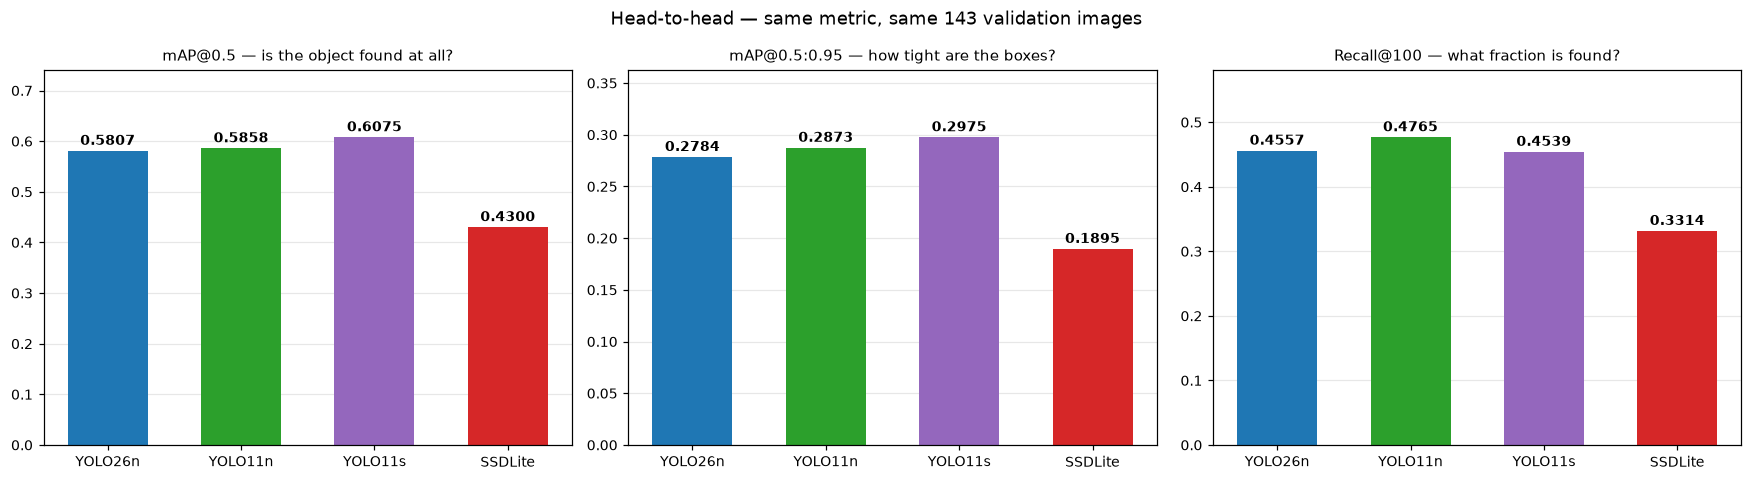

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))
metrics = [("mAP50", "mAP@0.5 — is the object found at all?"),
           ("mAP50-95", "mAP@0.5:0.95 — how tight are the boxes?"),
           ("recall", "Recall@100 — what fraction is found?")]
for ax, (key, title) in zip(axes, metrics):
    vals = [results[t][{"recall":"recall_100"}.get(key, key)] for t in ORDER]
    bars = ax.bar(ORDER, vals, color=[COLORS[t] for t in ORDER], width=.6)
    for b, v in zip(bars, vals):
        ax.text(b.get_x()+b.get_width()/2, v+max(vals)*0.02, f"{v:.4f}",
                ha="center", fontsize=9, fontweight="bold")
    ax.set_title(title, fontsize=10); ax.set_ylim(0, max(vals)*1.22)
    ax.grid(axis="y", alpha=.3); ax.set_axisbelow(True)
plt.suptitle("Head-to-head — same metric, same 143 validation images", fontsize=12)
plt.tight_layout(); plt.show()

Small objects are distant workers — goggles and gloves at range.
This is usually where a 320px input loses to a 640px one.


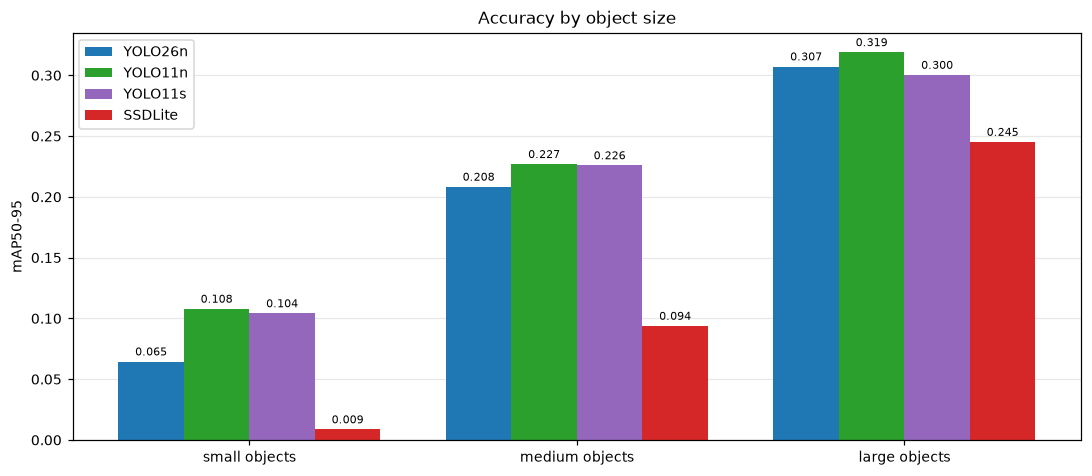

In [7]:
# Accuracy by object size — where does each architecture actually differ?
fig, ax = plt.subplots(figsize=(10, 4.4))
sizes = ["mAP_small", "mAP_medium", "mAP_large"]
x = np.arange(len(sizes)); w = 0.8/len(ORDER)
for i, t in enumerate(ORDER):
    vals = [max(results[t][s], 0) for s in sizes]
    b = ax.bar(x + i*w - 0.4 + w/2, vals, w, label=t, color=COLORS[t])
    for bb, v in zip(b, vals):
        ax.text(bb.get_x()+bb.get_width()/2, v+0.005, f"{v:.3f}", ha="center", fontsize=7.5)
ax.set_xticks(x); ax.set_xticklabels(["small objects","medium objects","large objects"])
ax.set_ylabel("mAP50-95"); ax.set_title("Accuracy by object size")
ax.legend(fontsize=9); ax.grid(axis="y", alpha=.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()
print("Small objects are distant workers — goggles and gloves at range.")
print("This is usually where a 320px input loses to a 640px one.")

## 6. Per-class — the comparison that actually matters

A single mAP number hides the thing this dataset is about. Compliance detection lives or
dies on the `no_*` classes.

In [8]:
train_counts = Counter()
for lbl in (DATA_ROOT/"labels"/"train").glob("*.txt"):
    for line in lbl.read_text().strip().splitlines():
        if line.strip():
            train_counts[int(line.split()[0])] += 1

classes = [CLASS_NAMES[i] for i in range(11)]
pc = pd.DataFrame({t: [per_class[t].get(c, 0.0) for c in classes] for t in ORDER},
                  index=classes)
pc["train_instances"] = [train_counts.get(i, 0) for i in range(11)]
pc = pc.sort_values(ORDER[0], ascending=False)

display(pc.style.format({**{t: "{:.4f}" for t in ORDER}, "train_instances": "{:.0f}"})
        .background_gradient(cmap="RdYlGn", subset=ORDER, vmin=0, vmax=0.6))

,YOLO26n,YOLO11n,YOLO11s,SSDLite,train_instances
Person,0.5093,0.5099,0.4997,0.4577,1790
vest,0.4959,0.5202,0.5068,0.4206,1283
boots,0.4258,0.4449,0.4505,0.3223,1251
helmet,0.4095,0.4335,0.4388,0.2754,1357
gloves,0.3847,0.3855,0.3997,0.1449,1162
goggles,0.3610,0.3811,0.3812,0.1231,427
none,0.1834,0.1945,0.1833,0.2000,654
no_helmet,0.0905,0.1630,0.1191,0.0876,400
no_boots,0.0793,0.0110,0.1509,0.0090,88
no_gloves,0.0627,0.0722,0.0900,0.0160,442


Correlation between training frequency and per-class accuracy:
  YOLO26n   r = +0.815
  YOLO11n   r = +0.860
  YOLO11s   r = +0.764
  SSDLite   r = +0.825


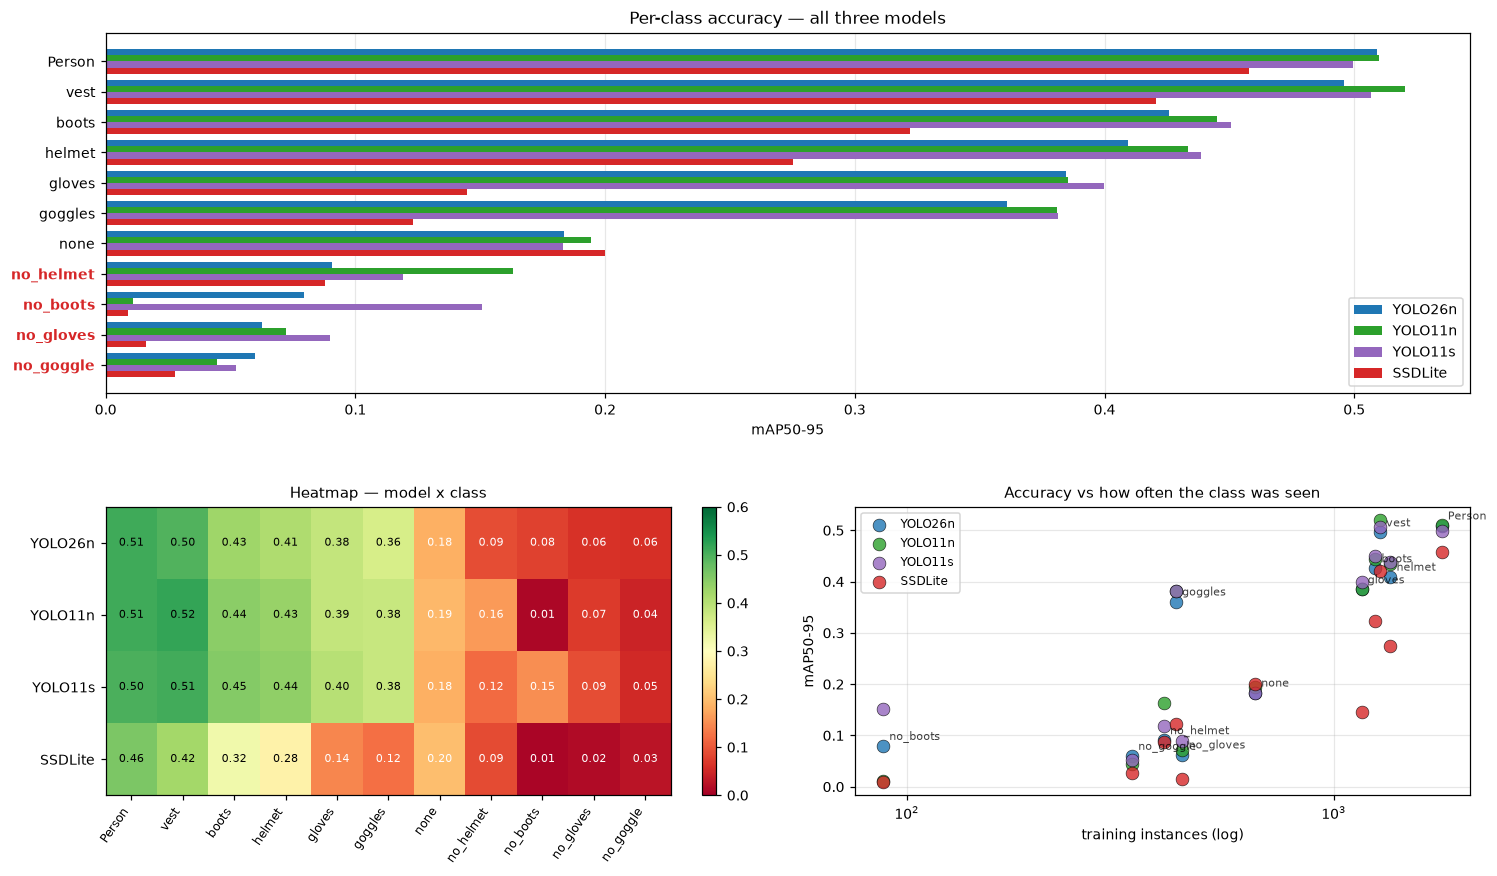

In [9]:
fig = plt.figure(figsize=(16, 9))
gs = fig.add_gridspec(2, 2, height_ratios=[1.25, 1], hspace=.35, wspace=.22)

# --- grouped per-class bars ---------------------------------------------
ax = fig.add_subplot(gs[0, :])
y = np.arange(len(pc)); h = 0.8/len(ORDER)
for i, t in enumerate(ORDER):
    ax.barh(y + i*h - 0.4 + h/2, pc[t], h, label=t, color=COLORS[t])
ax.set_yticks(y); ax.set_yticklabels(pc.index); ax.invert_yaxis()
ax.set_xlabel("mAP50-95"); ax.set_title("Per-class accuracy — all three models", fontsize=11)
ax.legend(fontsize=9); ax.grid(axis="x", alpha=.3); ax.set_axisbelow(True)
for lbl in ax.get_yticklabels():
    if lbl.get_text().startswith("no_"):
        lbl.set_color("#d62728"); lbl.set_fontweight("bold")

# --- heatmap -------------------------------------------------------------
ax = fig.add_subplot(gs[1, 0])
mat = pc[ORDER].values.T
im = ax.imshow(mat, cmap="RdYlGn", aspect="auto", vmin=0, vmax=0.6)
ax.set_xticks(range(len(pc))); ax.set_xticklabels(pc.index, rotation=55, ha="right", fontsize=8)
ax.set_yticks(range(len(ORDER))); ax.set_yticklabels(ORDER, fontsize=9)
for i in range(len(ORDER)):
    for j in range(len(pc)):
        ax.text(j, i, f"{mat[i,j]:.2f}", ha="center", va="center", fontsize=7,
                color="black" if mat[i,j] > 0.2 else "white")
ax.set_title("Heatmap — model x class", fontsize=10)
plt.colorbar(im, ax=ax, fraction=.03)

# --- accuracy vs rarity --------------------------------------------------
ax = fig.add_subplot(gs[1, 1])
for t in ORDER:
    ax.scatter(pc["train_instances"], pc[t], s=70, alpha=.8, label=t,
               color=COLORS[t], edgecolors="black", linewidths=.4, zorder=3)
for c in pc.index:
    ax.annotate(c, (pc.loc[c,"train_instances"], pc.loc[c,ORDER[0]]),
                fontsize=7, xytext=(4,4), textcoords="offset points", alpha=.75)
ax.set_xscale("symlog"); ax.set_xlabel("training instances (log)")
ax.set_ylabel("mAP50-95"); ax.set_title("Accuracy vs how often the class was seen", fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.show()

# how strongly does rarity explain accuracy?
print("Correlation between training frequency and per-class accuracy:")
for t in ORDER:
    r = np.corrcoef(np.log10(pc["train_instances"].clip(lower=1)), pc[t])[0,1]
    print(f"  {t:<9} r = {r:+.3f}")

> **The scatter is the headline finding of this whole project.**
>
> All three models — two different YOLO generations and a completely unrelated SSD
> architecture — produce nearly the same per-class ranking, and it tracks training
> frequency. The correlation coefficients printed above quantify it.
>
> That is three independent pieces of evidence for the same conclusion: **the ceiling on
> the `no_*` classes is the data, not the model.** Swapping architectures moves the
> headline mAP by a couple of points and moves `no_goggle` essentially not at all.
>
> Which means the productive next step is not a fourth model. It is either merging the
> `no_*` classes into a single `missing_ppe` class so their examples pool, or labelling
> more of them.

## 7. Speed, size, and the trade-off

Latency is measured with one harness on one device: same images, same warmup, single
image at a time — the way a video stream actually arrives.

In [10]:
bench_imgs = [g["path"] for g in GT[:10]]

def bench(entry, runs=30, warmup=5):
    for i in range(warmup):
        predict(entry, bench_imgs[i % len(bench_imgs)], GT[i % len(GT)]["hw"], conf=0.25)
    sync()
    ts = []
    for i in range(runs):
        k = i % len(bench_imgs)
        t0 = time.perf_counter()
        predict(entry, bench_imgs[k], GT[k]["hw"], conf=0.25)
        sync()
        ts.append((time.perf_counter()-t0)*1000)
    return np.array(ts)

speed = {}
for t in ORDER:
    ts = bench(models[t])
    speed[t] = {"mean_ms": float(ts.mean()), "median_ms": float(np.median(ts)),
                "p90_ms": float(np.percentile(ts, 90)), "fps": 1000/float(ts.mean())}
    print(f"  {t:<9} {ts.mean():7.2f} ms   {1000/ts.mean():7.1f} FPS")

comp["fps"] = [speed[t]["fps"] for t in ORDER]
comp["latency_ms"] = [speed[t]["mean_ms"] for t in ORDER]

  YOLO26n      9.15 ms     109.2 FPS
  YOLO11n      9.83 ms     101.7 FPS
  YOLO11s     15.71 ms      63.7 FPS
  SSDLite     19.63 ms      50.9 FPS


Top-right is the ideal corner: fast and accurate.
  YOLO26n   0.2784 mAP50-95 @  109.2 FPS, 5.2 MB on disk
  YOLO11n   0.2873 mAP50-95 @  101.7 FPS, 5.2 MB on disk
  YOLO11s   0.2975 mAP50-95 @   63.7 FPS, 18.3 MB on disk
  SSDLite   0.1895 mAP50-95 @   50.9 FPS, 9.2 MB on disk


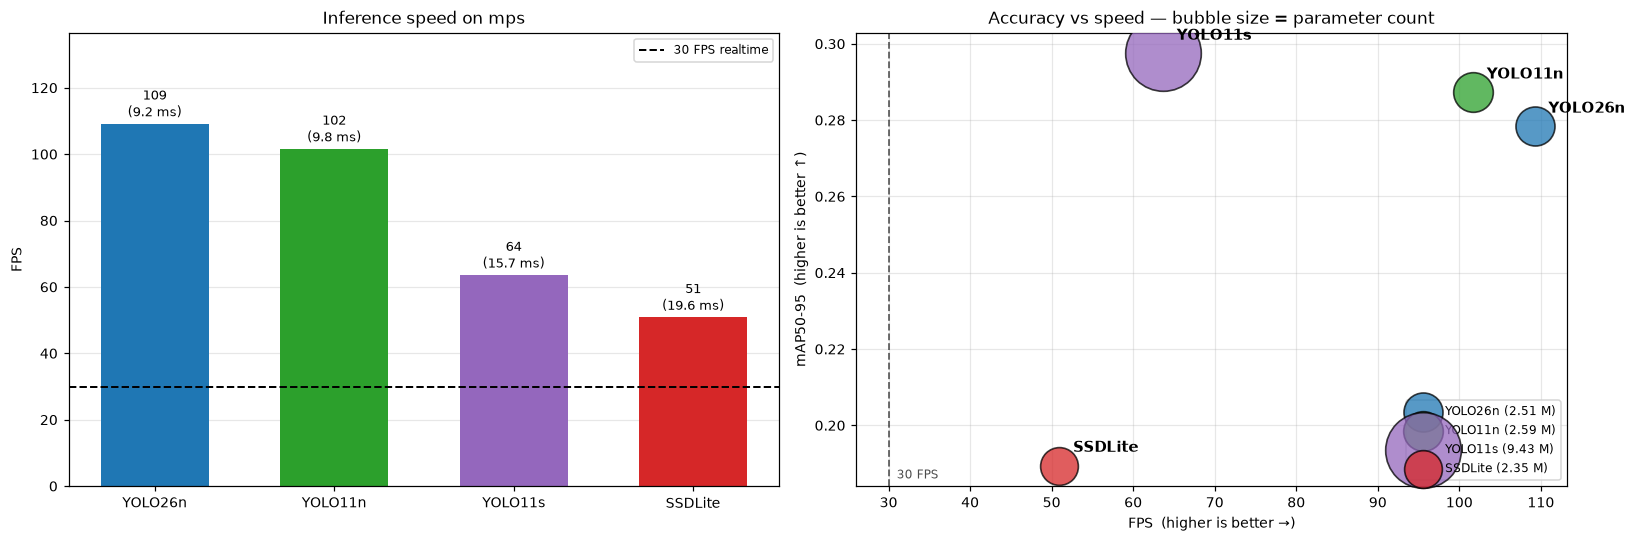

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# --- speed bars ----------------------------------------------------------
ax = axes[0]
vals = [speed[t]["fps"] for t in ORDER]
bars = ax.bar(ORDER, vals, color=[COLORS[t] for t in ORDER], width=.6)
ax.axhline(30, ls="--", c="black", lw=1.3, label="30 FPS realtime")
for b, v, t in zip(bars, vals, ORDER):
    ax.text(b.get_x()+b.get_width()/2, v+max(vals)*0.02,
            f"{v:.0f}\n({speed[t]['mean_ms']:.1f} ms)", ha="center", fontsize=8.5)
ax.set_ylabel("FPS"); ax.set_title(f"Inference speed on {DEVICE}")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=.3); ax.set_axisbelow(True)
ax.set_ylim(0, max(vals)*1.25)

# --- the trade-off plot --------------------------------------------------
ax = axes[1]
for t in ORDER:
    ax.scatter(speed[t]["fps"], results[t]["mAP50-95"],
               s=comp.loc[t,"params_M"]*260, color=COLORS[t], alpha=.75,
               edgecolors="black", linewidths=1.1, zorder=3, label=f"{t} ({comp.loc[t,'params_M']:.2f} M)")
    ax.annotate(t, (speed[t]["fps"], results[t]["mAP50-95"]),
                xytext=(9, 9), textcoords="offset points", fontsize=9.5, fontweight="bold")
ax.axvline(30, ls="--", c="black", lw=1.2, alpha=.6)
ax.text(31, ax.get_ylim()[0]+0.002, "30 FPS", fontsize=8, alpha=.7)
ax.set_xlabel("FPS  (higher is better →)"); ax.set_ylabel("mAP50-95  (higher is better ↑)")
ax.set_title("Accuracy vs speed — bubble size = parameter count")
ax.grid(alpha=.3); ax.legend(fontsize=8, loc="lower right")
plt.tight_layout(); plt.show()

print("Top-right is the ideal corner: fast and accurate.")
for t in ORDER:
    print(f"  {t:<9} {results[t]['mAP50-95']:.4f} mAP50-95 @ {speed[t]['fps']:6.1f} FPS, "
          f"{comp.loc[t,'size_MB']:.1f} MB on disk")

## 8. How they got there

Training curves overlaid. The two Ultralytics runs and the torchvision run log different
columns, so each is read on its own terms and only the mAP series is compared.

model       best mAP50-95  at epoch     final    overfit?
------------------------------------------------------------
YOLO26n            0.2857        87    0.2769   yes, mild
YOLO11n            0.2865        57    0.2843   plateaued
YOLO11s            0.2981        44    0.2811   yes, mild
SSDLite            0.1895        24    0.1791   yes, mild


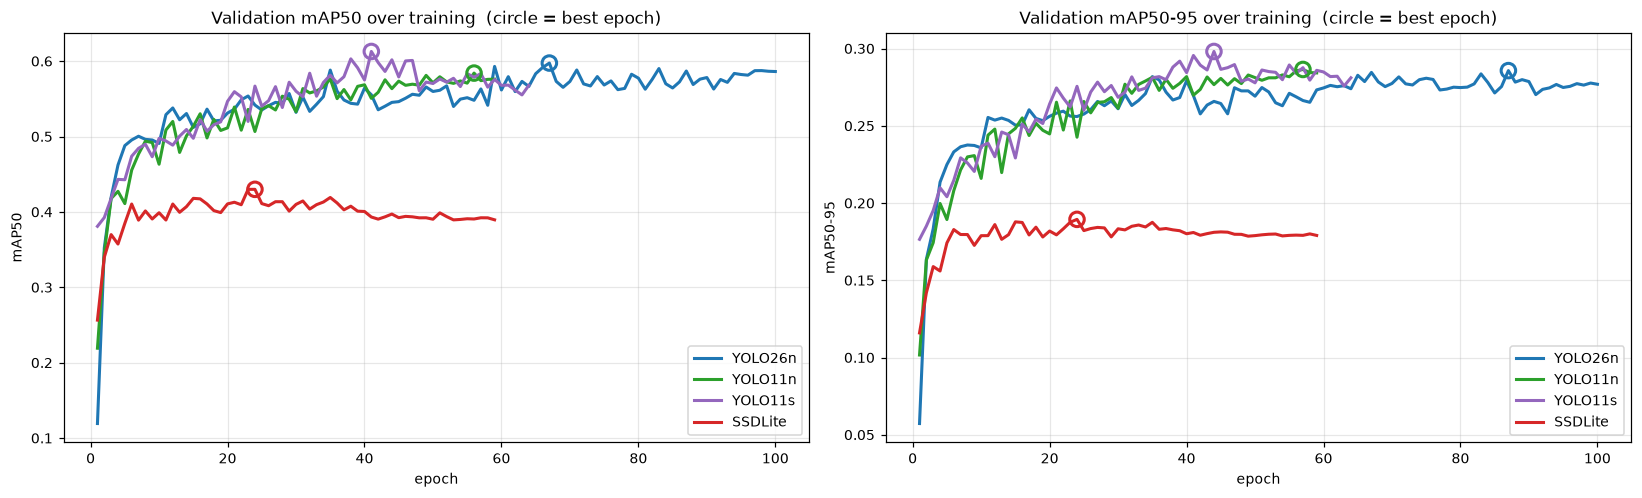

In [12]:
curves = {}
for tag, run in [("YOLO26n","yolo26n"), ("YOLO11n","yolo11n"),
                 ("YOLO11s","yolo11s"), ("SSDLite","ssdlite")]:
    f = RUNS_DIR / run / "results.csv"
    if not f.exists():
        f = PROJECT / "training_logs" / f"{run}_results.csv"   # committed fallback
    if not f.exists():
        continue
    d = pd.read_csv(f); d.columns = [c.strip() for c in d.columns]
    if "metrics/mAP50(B)" in d.columns:        # Ultralytics layout
        curves[tag] = pd.DataFrame({"epoch": d["epoch"],
                                    "mAP50": d["metrics/mAP50(B)"],
                                    "mAP50-95": d["metrics/mAP50-95(B)"]})
    elif "mAP50" in d.columns:                 # our SSDLite loop
        curves[tag] = d[["epoch","mAP50","mAP50-95"]].copy()

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
for key, ax in zip(["mAP50","mAP50-95"], axes):
    for t, d in curves.items():
        ax.plot(d["epoch"], d[key], lw=2, color=COLORS[t], label=t)
        k = d[key].idxmax()
        ax.scatter(d.loc[k,"epoch"], d.loc[k,key], s=90, facecolors="none",
                   edgecolors=COLORS[t], linewidths=2, zorder=5)
    ax.set_xlabel("epoch"); ax.set_ylabel(key)
    ax.set_title(f"Validation {key} over training  (circle = best epoch)")
    ax.legend(fontsize=9); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"{'model':<10}{'best mAP50-95':>15}{'at epoch':>10}{'final':>10}{'overfit?':>12}")
print("-"*60)
for t, d in curves.items():
    k = d["mAP50-95"].idxmax()
    be, bv, fv = int(d.loc[k,"epoch"]), d.loc[k,"mAP50-95"], d["mAP50-95"].iloc[-1]
    drift = bv - fv
    note = "yes, mild" if drift > 0.005 else ("plateaued" if drift > -0.002 else "still rising")
    print(f"{t:<10}{bv:>15.4f}{be:>10}{fv:>10.4f}{note:>12}")

## 9. Same image, three models

Metrics summarise; looking at output tells you what the differences actually mean.

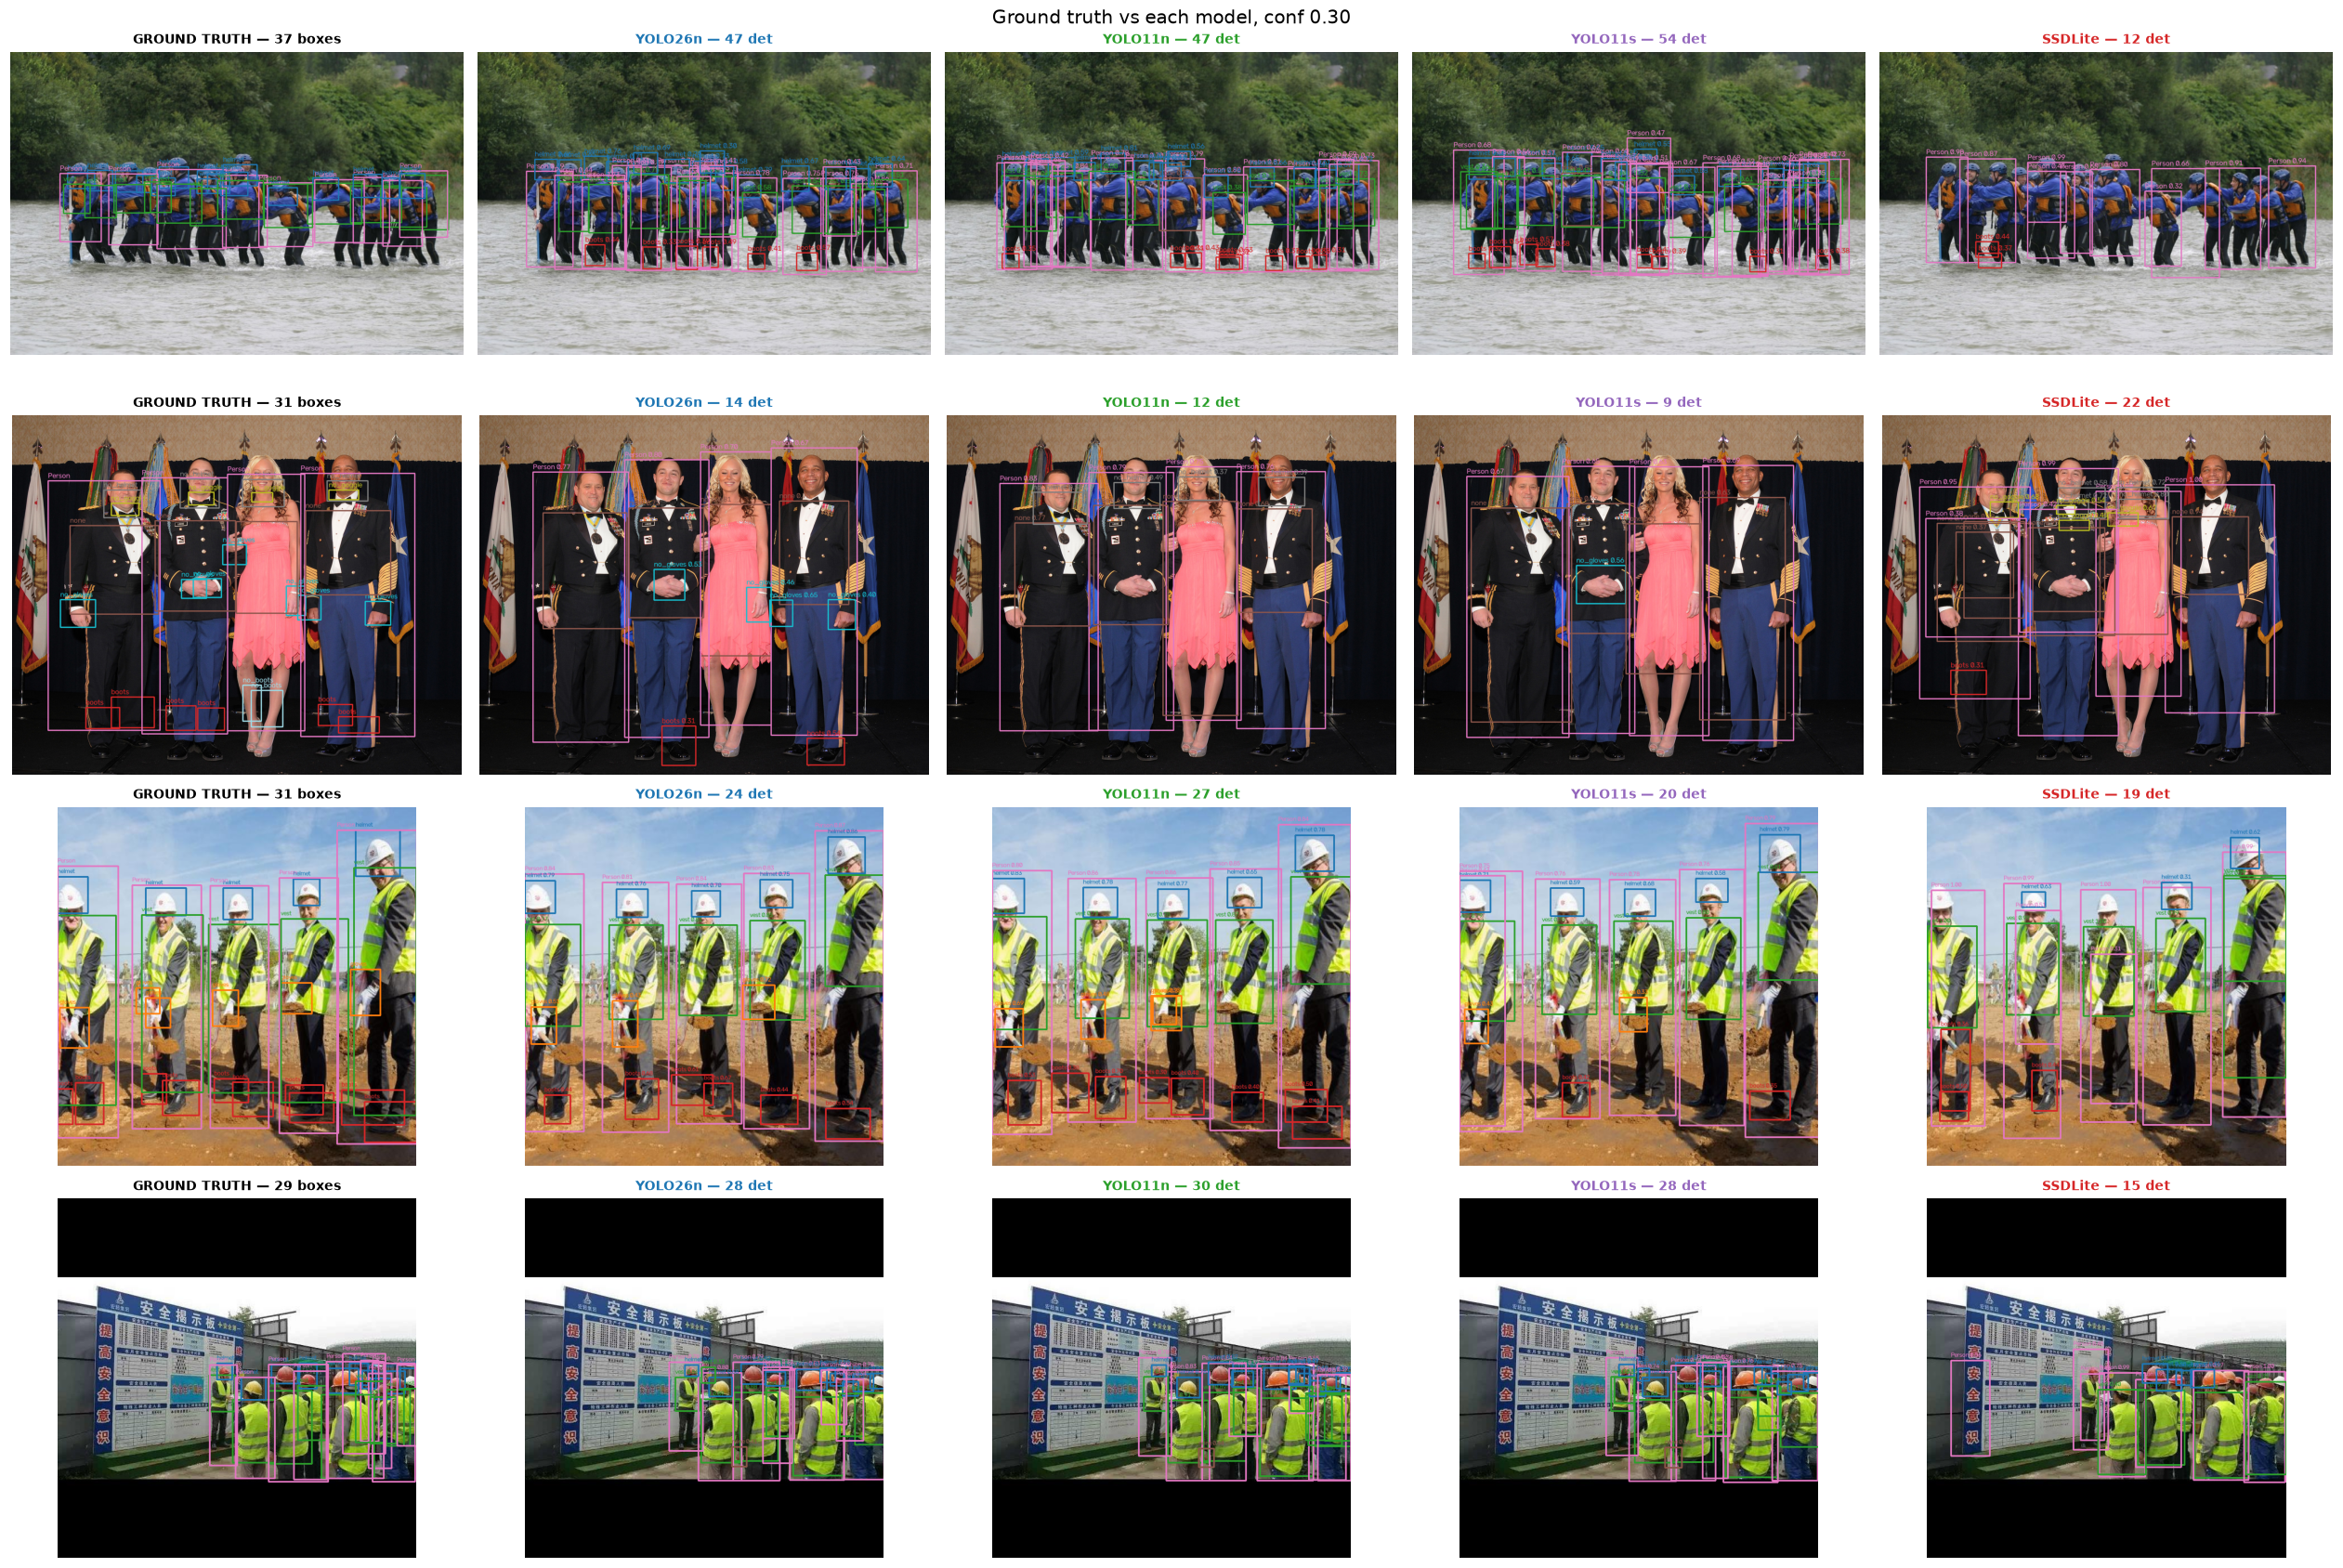

In [13]:
PALETTE = plt.cm.tab20(np.linspace(0, 1, 11))[:, :3] * 255

def annotate(img_path, boxes, scores, labels, conf=0.3):
    img = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    scale = max(img.shape[:2]) / 900
    for (x1,y1,x2,y2), s, c in zip(boxes.tolist(), scores.tolist(), labels.tolist()):
        if s < conf or not (0 <= int(c) < 11):
            continue
        col = tuple(int(v) for v in PALETTE[int(c)])
        cv2.rectangle(img, (int(x1),int(y1)), (int(x2),int(y2)), col, max(2, int(2*scale)))
        cv2.putText(img, f"{CLASS_NAMES[int(c)]} {s:.2f}", (int(x1), max(int(y1)-6, 14)),
                    cv2.FONT_HERSHEY_SIMPLEX, .5*scale, col, max(1, int(1.5*scale)))
    return img

def gt_image(g):
    img = cv2.cvtColor(cv2.imread(str(g["path"])), cv2.COLOR_BGR2RGB)
    scale = max(img.shape[:2]) / 900
    for (x1,y1,x2,y2), c in zip(g["boxes"].tolist(), g["labels"].tolist()):
        col = tuple(int(v) for v in PALETTE[int(c)])
        cv2.rectangle(img, (int(x1),int(y1)), (int(x2),int(y2)), col, max(2, int(2*scale)))
        cv2.putText(img, CLASS_NAMES[int(c)], (int(x1), max(int(y1)-6, 14)),
                    cv2.FONT_HERSHEY_SIMPLEX, .5*scale, col, max(1, int(1.5*scale)))
    return img

# pick a few busy images — they show the differences best
picks = sorted(range(len(GT)), key=lambda i: -len(GT[i]["labels"]))[:4]

ncol = 1 + len(ORDER)
fig, axes = plt.subplots(len(picks), ncol, figsize=(4.6*ncol, 3.9*len(picks)))
for row, idx in zip(axes, picks):
    g = GT[idx]
    row[0].imshow(gt_image(g))
    row[0].set_title(f"GROUND TRUTH — {len(g['labels'])} boxes", fontsize=9, fontweight="bold")
    row[0].axis("off")
    for ax, t in zip(row[1:], ORDER):
        b, s, c = predict(models[t], g["path"], g["hw"], conf=0.25)
        keep = s >= 0.3
        ax.imshow(annotate(g["path"], b[keep], s[keep], c[keep]))
        ax.set_title(f"{t} — {int(keep.sum())} det", fontsize=9, color=COLORS[t],
                     fontweight="bold")
        ax.axis("off")
plt.suptitle("Ground truth vs each model, conf 0.30", fontsize=13)
plt.tight_layout(); plt.show()

model       detections     vs GT   median conf
------------------------------------------------
YOLO26n           1072     0.91x         0.779
YOLO11n           1087     0.93x         0.773
YOLO11s           1076     0.92x         0.714
SSDLite            864     0.74x         0.963
(truth)           1172     1.00x


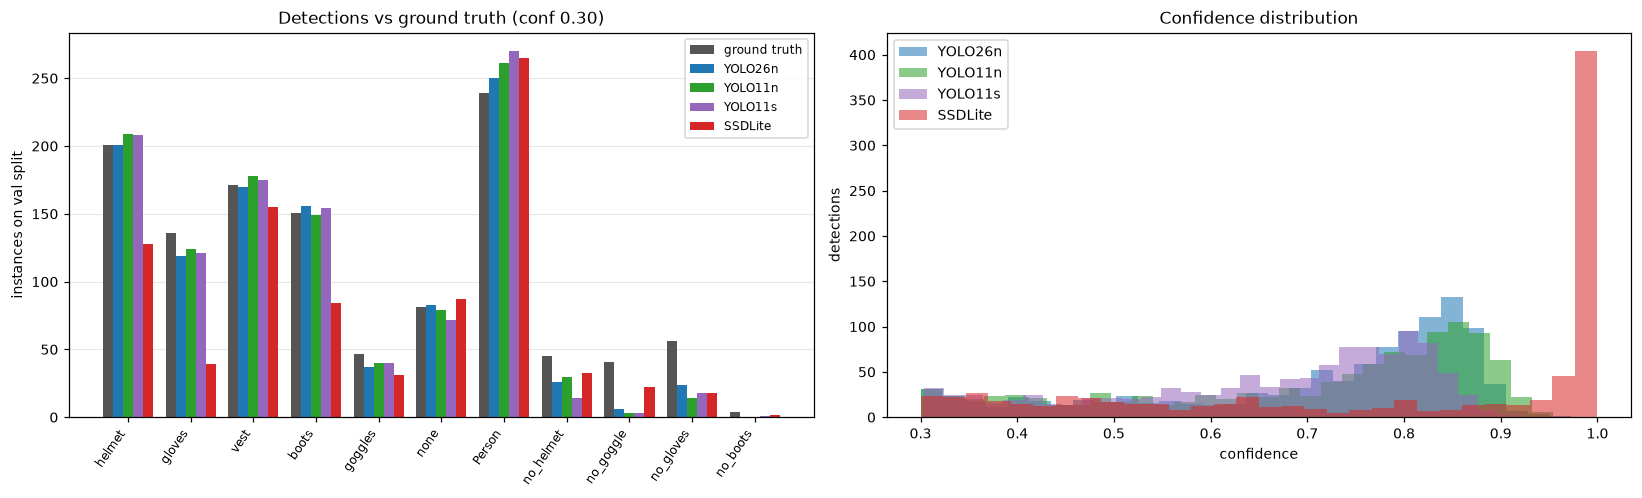

In [14]:
# How many detections does each model make, and how confident is it?
counts_by_model, confs_by_model = {}, {}
for t in ORDER:
    cc, ss = Counter(), []
    for g in GT:
        b, s, c = predict(models[t], g["path"], g["hw"], conf=0.25)
        for cls, sc in zip(c.tolist(), s.tolist()):
            if sc >= 0.3 and 0 <= int(cls) < 11:
                cc[CLASS_NAMES[int(cls)]] += 1; ss.append(sc)
    counts_by_model[t], confs_by_model[t] = cc, ss

gt_counts = Counter()
for g in GT:
    for c in g["labels"].tolist():
        gt_counts[CLASS_NAMES[int(c)]] += 1

fig, axes = plt.subplots(1, 2, figsize=(15, 4.6))
ax = axes[0]
idx = np.arange(len(classes)); w = 0.8/(len(ORDER)+1)
ax.bar(idx - 0.4 + w/2, [gt_counts.get(c,0) for c in classes], w,
       label="ground truth", color="#555555")
for i, t in enumerate(ORDER, start=1):
    ax.bar(idx + i*w - 0.4 + w/2, [counts_by_model[t].get(c,0) for c in classes], w,
           label=t, color=COLORS[t])
ax.set_xticks(idx); ax.set_xticklabels(classes, rotation=55, ha="right", fontsize=8)
ax.set_ylabel("instances on val split"); ax.set_title("Detections vs ground truth (conf 0.30)")
ax.legend(fontsize=8); ax.grid(axis="y", alpha=.3); ax.set_axisbelow(True)

ax = axes[1]
for t in ORDER:
    if confs_by_model[t]:
        ax.hist(confs_by_model[t], bins=30, alpha=.55, label=t, color=COLORS[t])
ax.set_xlabel("confidence"); ax.set_ylabel("detections")
ax.set_title("Confidence distribution"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

print(f"{'model':<10}{'detections':>12}{'vs GT':>10}{'median conf':>14}")
print("-"*48)
tot_gt = sum(gt_counts.values())
for t in ORDER:
    n = sum(counts_by_model[t].values())
    print(f"{t:<10}{n:>12}{n/tot_gt:>9.2f}x{np.median(confs_by_model[t]):>14.3f}")
print(f"{'(truth)':<10}{tot_gt:>12}{1.0:>9.2f}x")

> A model detecting far **fewer** boxes than ground truth is under-firing — it will miss
> non-compliance. One detecting far **more** is over-firing, which floods a real
> deployment with false alarms. The ratio column above is the quick read on which
> failure mode each model leans toward.

## 10. Verdict

WINNER: YOLO11n
  0.2873 mAP50-95 · 102 FPS · 5.2 MB · 2.59 M params


,params_M,size_MB,mAP50,mAP50-95,recall,fps,score
model,,,,,,,
YOLO11n,2.59,5.22,0.5858,0.2873,0.4765,101.7,0.916
YOLO26n,2.51,5.15,0.5807,0.2784,0.4557,109.2,0.870
YOLO11s,9.43,18.30,0.6075,0.2975,0.4539,63.7,0.803
SSDLite,2.35,9.21,0.4300,0.1895,0.3314,50.9,0.055


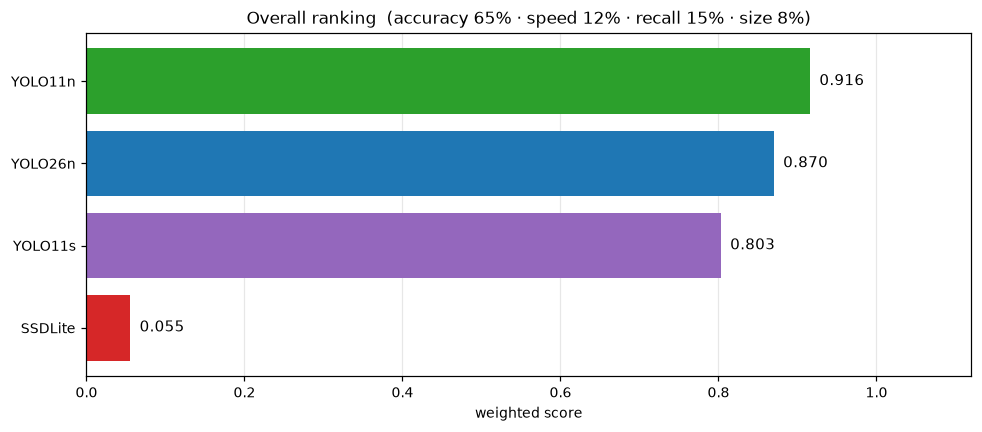

In [15]:
# Composite score. Weights reflect what this application needs: accuracy first,
# then realtime-capability, then size. Adjust them to match your own priorities.
W = {"mAP50-95": 0.40, "mAP50": 0.25, "recall": 0.15, "fps": 0.12, "size": 0.08}

norm = {}
for key, col in [("mAP50-95","mAP50-95"), ("mAP50","mAP50"), ("recall","recall"), ("fps","fps")]:
    v = comp[col].astype(float)
    norm[key] = (v - v.min()) / (v.max() - v.min()) if v.max() > v.min() else v*0 + 1
s = comp["size_MB"].astype(float)
norm["size"] = (s.max() - s) / (s.max() - s.min()) if s.max() > s.min() else s*0 + 1

comp["score"] = sum(norm[k]*w for k, w in W.items())
ranked = comp.sort_values("score", ascending=False)

display(ranked[["params_M","size_MB","mAP50","mAP50-95","recall","fps","score"]]
        .style.format({"params_M":"{:.2f}","size_MB":"{:.2f}","mAP50":"{:.4f}",
                       "mAP50-95":"{:.4f}","recall":"{:.4f}","fps":"{:.1f}","score":"{:.3f}"})
        .background_gradient(cmap="Greens", subset=["score"]))

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(ranked.index, ranked["score"], color=[COLORS[t] for t in ranked.index])
for b, v in zip(bars, ranked["score"]):
    ax.text(v+0.012, b.get_y()+b.get_height()/2, f"{v:.3f}", va="center", fontsize=9.5)
ax.invert_yaxis(); ax.set_xlabel("weighted score"); ax.set_xlim(0, 1.12)
ax.set_title("Overall ranking  (accuracy 65% · speed 12% · recall 15% · size 8%)")
ax.grid(axis="x", alpha=.3); ax.set_axisbelow(True)
plt.tight_layout(); plt.show()

win = ranked.index[0]
print(f"WINNER: {win}")
print(f"  {ranked.loc[win,'mAP50-95']:.4f} mAP50-95 · {ranked.loc[win,'fps']:.0f} FPS · "
      f"{ranked.loc[win,'size_MB']:.1f} MB · {ranked.loc[win,'params_M']:.2f} M params")

In [16]:
# Save everything so the README and any report can quote exact figures.
payload = {
    "evaluated_on": {"split": "val", "images": len(GT),
                     "boxes": int(sum(len(g['labels']) for g in GT)),
                     "device": str(DEVICE),
                     "metric": "torchmetrics MeanAveragePrecision, max_det=[1,10,100] (COCO standard), conf>=0.001"},
    "models": {t: {"params_M": float(comp.loc[t,"params_M"]),
                   "size_MB": float(comp.loc[t,"size_MB"]),
                   "input_px": int(comp.loc[t,"input_px"]),
                   "metrics": results[t],
                   "per_class": per_class[t],
                   "speed": speed[t],
                   "score": float(comp.loc[t,"score"])} for t in ORDER},
    "ranking": list(ranked.index),
}
(OUT_DIR / "comparison.json").write_text(json.dumps(payload, indent=2))
comp.to_csv(OUT_DIR / "comparison.csv")
pc.to_csv(OUT_DIR / "per_class.csv")

print(f"saved -> {OUT_DIR/'comparison.json'}")
print(f"saved -> {OUT_DIR/'comparison.csv'}")
print(f"saved -> {OUT_DIR/'per_class.csv'}")
print()
print("="*72)
print("  SUMMARY")
print("="*72)
for i, t in enumerate(ranked.index, 1):
    print(f"  {i}. {t:<9} mAP50 {results[t]['mAP50']:.4f} | "
          f"mAP50-95 {results[t]['mAP50-95']:.4f} | "
          f"{speed[t]['fps']:5.1f} FPS | {comp.loc[t,'size_MB']:.1f} MB")
print("="*72)
weak = [c for c in classes if all(per_class[t].get(c,0) < 0.15 for t in ORDER)]
print(f"  Classes all three models fail (<0.15 mAP50-95): {', '.join(weak) if weak else 'none'}")
print(f"  Their share of training data: "
      f"{sum(train_counts.get(classes.index(c),0) for c in weak)/sum(train_counts.values())*100:.1f}%")
print("="*72)

saved -> /Users/shamprakashr/Documents/VibeCoding/Agent Skills/PPE_Detection/comparison/comparison.json
saved -> /Users/shamprakashr/Documents/VibeCoding/Agent Skills/PPE_Detection/comparison/comparison.csv
saved -> /Users/shamprakashr/Documents/VibeCoding/Agent Skills/PPE_Detection/comparison/per_class.csv

  SUMMARY
  1. YOLO11n   mAP50 0.5858 | mAP50-95 0.2873 | 101.7 FPS | 5.2 MB
  2. YOLO26n   mAP50 0.5807 | mAP50-95 0.2784 | 109.2 FPS | 5.2 MB
  3. YOLO11s   mAP50 0.6075 | mAP50-95 0.2975 |  63.7 FPS | 18.3 MB
  4. SSDLite   mAP50 0.4300 | mAP50-95 0.1895 |  50.9 FPS | 9.2 MB
  Classes all three models fail (<0.15 mAP50-95): no_goggle, no_gloves
  Their share of training data: 8.5%


## What to do with this

The ranking above answers "which of these three should I deploy". It does not answer
"is this good enough", and on the evidence here the honest answer to the second question
is **not yet for compliance use** — whichever model wins.

The classes listed in the last line are the ones every architecture fails on, and they
are the ones a PPE system exists to catch. All three agreeing, despite different
families, different frameworks and different input resolutions, is about as clear a
signal as this kind of experiment gives: **more architecture search will not move them.**

Ranked by expected payoff:

1. **Merge the `no_*` classes** into one `missing_ppe` class. Pools their scarce examples
   into one better-supported class, and "this person is non-compliant" is usually the
   actual business requirement — the specific missing item is often not needed.
2. **Oversample** images containing rare classes so they appear more often per epoch, or
   weight the loss by inverse class frequency.
3. **Label more data** for the missing-PPE cases. The real fix, and the expensive one.
4. **Only then** revisit the architecture — and at that point a larger model becomes worth
   testing, because capacity would no longer be the thing holding it back.